In [ ]:
import zipfile

# Kini ang mo-extract sa imong zip file para makita ang mga folders
with zipfile.ZipFile('plants_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction complete! Tan-awa ang imong sidebar sa wala, naa na ang folders.")

BadZipFile: File is not a zip file

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# This extracts the files into Colab's local memory
!unzip -o -q /content/drive/MyDrive/plants_Dataset.zip -d /content/


Mounted at /content/drive


In [19]:
import pathlib
import tensorflow as tf

# 1. Sigurohon nato ang location sa folder
data_dir = pathlib.Path('/content/plants_Dataset')

# 2. I-load ang training images
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(180, 180),
  batch_size=32)

# 3. I-load ang validation images
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(180, 180),
  batch_size=32)

class_names = train_ds.class_names
print(f"Human na! Nakakita ang AI og: {class_names}")

Found 6494 files belonging to 20 classes.
Using 5196 files for training.
Found 6494 files belonging to 20 classes.
Using 1298 files for validation.
Human na! Nakakita ang AI og: ['African_Violet', 'Air_Plant', 'Black_Bat_Flower', 'Bleeding_Heart', 'Caladium', 'Cockscomb', 'Coleus', 'Copperleaf', 'Fiddle_Leaf_Fig', 'Hydrangea', 'Jade_Vine', 'Japanese_Blood_Grass', 'Prayer_Plant', 'Purple_Fountain_Grass', 'Silver_Inch_Plant', 'Snake_Plant', 'Spathiphyllum', 'Strelitzia', 'String_of_Pearls', 'Swiss_Cheese_Plant']


In [16]:
import os
import tensorflow as tf

def filter_broken_images(directory):
    print("Sige, i-scan nato og maayo...")
    count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    # Sulayan og abli ang file gamit ang TensorFlow mismo
                    img_raw = tf.io.read_file(file_path)
                    tf.io.decode_image(img_raw, channels=3, expand_animations=False)
                except Exception:
                    # Kung dili mabasa, i-delete dayon!
                    print(f"Removing broken file: {file_path}")
                    os.remove(file_path)
                    count += 1
    print(f"Nahuman na! {count} ka traydor nga files ang natangtang.")

filter_broken_images('/content/plants_Dataset')

Sige, i-scan nato og maayo...
Removing broken file: /content/plants_Dataset/Black_Bat_Flower/000170.jpg
Removing broken file: /content/plants_Dataset/Purple_Fountain_Grass/000272.jpg
Removing broken file: /content/plants_Dataset/Purple_Fountain_Grass/000147.jpg
Removing broken file: /content/plants_Dataset/Purple_Fountain_Grass/000271.jpg
Removing broken file: /content/plants_Dataset/String_of_Pearls/000275.jpg
Removing broken file: /content/plants_Dataset/String_of_Pearls/000248.jpg
Removing broken file: /content/plants_Dataset/String_of_Pearls/000105.jpg
Removing broken file: /content/plants_Dataset/String_of_Pearls/000350.jpg
Removing broken file: /content/plants_Dataset/String_of_Pearls/000122.jpg
Removing broken file: /content/plants_Dataset/Silver_Inch_Plant/000339.jpg
Removing broken file: /content/plants_Dataset/Hydrangea/000012.jpg
Removing broken file: /content/plants_Dataset/Hydrangea/000421.jpg
Removing broken file: /content/plants_Dataset/Hydrangea/000328.jpg
Removing brok

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Define the Model (The "Brain")
num_classes = 20
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

# 2. Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the model
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)


Epoch 1/10


163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.2460 - loss: 2.4230 - val_accuracy: 0.4445 - val_loss: 1.8502
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 278s 2s/step - accuracy: 0.5308 - loss: 1.5490 - val_accuracy: 0.5763 - val_loss: 1.4429
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.7104 - loss: 0.9789 - val_accuracy: 0.6841 - val_loss: 1.1384
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 285s 2s/step - accuracy: 0.8480 - loss: 0.5265 - val_accuracy: 0.7126 - val_loss: 1.2329
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9263 - loss: 0.2655 - val_accuracy: 0.7727 - val_loss: 1.0300
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9748 - loss: 0.0970 - val_accuracy: 0.7851 - val_loss: 1.1936
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.9881 - loss: 0.0479 - val_accuracy: 0.7897 - val_loss: 1.2441
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.9896 - loss: 0.0392 - val_accuracy: 0.776

In [ ]:
import os
from PIL import Image

data_dir = "/content/plants_Dataset"
valid_formats = ('.jpg', '.jpeg', '.png')
deleted_count = 0

for root, dirs, files in os.walk(data_dir):
    for file in files:
        file_path = os.path.join(root, file)

        # 1. Delete if it's not a standard image extension
        if not file_path.lower().endswith(valid_formats):
            os.remove(file_path)
            deleted_count += 1
            continue

        # 2. Delete if the file is corrupted
        try:
            with Image.open(file_path) as img:
                img.verify()
        except:
            os.remove(file_path)
            deleted_count += 1

print(f"✅ Cleanup finished! Deleted {deleted_count} broken images.")

✅ Cleanup finished! Deleted 0 broken images.


In [ ]:
import matplotlib.pyplot as plt

# 1. Extract accuracy and loss metrics (Notice the Capital 'A' in Accuracy!)
acc = history.history['accuracy']
val_acc = history.history['val_Accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# 2. Left Subplot: Accuracy over time
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.title('Plant Classifier: Accuracy over 10 Epochs')
plt.legend(loc='lower right')
plt.grid(True)

# 3. Right Subplot: Loss over time
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss Score')
plt.title('Plant Classifier: Loss over 10 Epochs')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()


KeyError: 'val_Accuracy'

In [ ]:
import os
import tensorflow as tf
from PIL import Image

data_dir = "/content/plants_Dataset"
deleted = 0

print("Starting Scorched Earth Cleanup...")

for root, dirs, files in os.walk(data_dir):
    for file in files:
        fpath = os.path.join(root, file)
        try:
            # Method 1: Try reading with TensorFlow
            img_raw = tf.io.read_file(fpath)
            img = tf.io.decode_image(img_raw)

            # Method 2: Try opening with PIL
            with Image.open(fpath) as img_pil:
                img_pil.verify()
        except Exception:
            print(f"❌ Deleting broken image: {fpath}")
            os.remove(fpath)
            deleted += 1

print(f"✅ DONE! Deleted {deleted} more broken images. Your dataset is now clean.")

Starting Scorched Earth Cleanup...
❌ Deleting broken image: /content/plants_Dataset/Hydrangea/000012.jpg
❌ Deleting broken image: /content/plants_Dataset/Hydrangea/000328.jpg
❌ Deleting broken image: /content/plants_Dataset/Hydrangea/000421.jpg
❌ Deleting broken image: /content/plants_Dataset/Silver_Inch_Plant/000339.jpg
❌ Deleting broken image: /content/plants_Dataset/Purple_Fountain_Grass/000271.jpg
❌ Deleting broken image: /content/plants_Dataset/Purple_Fountain_Grass/000147.jpg
❌ Deleting broken image: /content/plants_Dataset/Purple_Fountain_Grass/000272.jpg
❌ Deleting broken image: /content/plants_Dataset/African_Violet/000356.jpg
❌ Deleting broken image: /content/plants_Dataset/Fiddle_Leaf_Fig/000319.jpg
❌ Deleting broken image: /content/plants_Dataset/Fiddle_Leaf_Fig/000084.jpg
❌ Deleting broken image: /content/plants_Dataset/Fiddle_Leaf_Fig/000277.jpg
❌ Deleting broken image: /content/plants_Dataset/Fiddle_Leaf_Fig/000013.jpg
❌ Deleting broken image: /content/plants_Dataset/Fid

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step


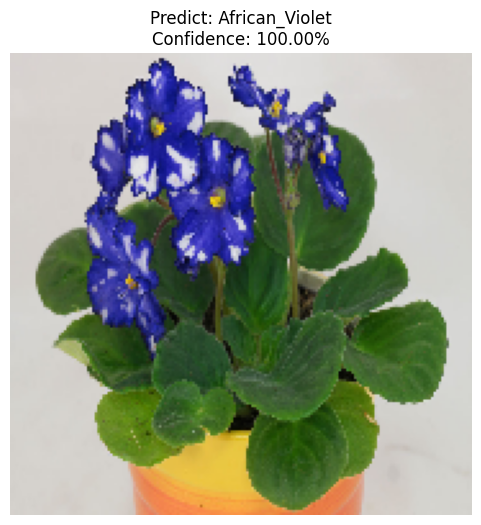

Kini nga tanom kay usa ka African_Violet (100.00%)


In [27]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Mao kini ang path nga imong gi-copy
img_path = "/content/plants_Dataset/African_Violet/000001.jpg"

# 2. Pag-load ug pag-process sa image para sa AI
img = tf.keras.utils.load_img(img_path, target_size=(180, 180))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# 3. Ang AI mo-predict na base sa iyang nakat-onan
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])
predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

# 4. I-display ang resulta uban ang picture para nindot tan-awon
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predict: {predicted_class}\nConfidence: {confidence:.2f}%")
plt.axis('off')
plt.show()

print(f"Kini nga tanom kay usa ka {predicted_class} ({confidence:.2f}%)")

In [ ]:
model.save('my_plant_ai.h5')

In [ ]:
import tensorflow as tf

# This loads the saved knowledge from your .h5 file
model = tf.keras.models.load_model('my_plant_ai.h5')

print("Success! Your AI is now awake and ready.")

Success! Your AI is now awake and ready.


In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

# 1. This will create a button to upload a photo from your computer
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. This prepares the image for the AI
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  # 3. The AI makes its prediction
  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  # 4. Show the final answer
  plant_name = train_ds.class_names[np.argmax(score)]
  confidence = 100 * np.max(score)

  print(f"\n------------------------------------")
  print(f"AI ANALYSIS: This looks like a {plant_name}!")
  print(f"CONFIDENCE: {confidence:.2f}%")
  print(f"------------------------------------")

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
import numpy as np
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

# 1. Load the 'Brain' you are currently uploading
# This line only works once that loading circle on the left is GONE
model = tf.keras.models.load_model('my_plant_ai.h5')

# 2. These are the plant names (Labels)
class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

print("AI is ONLINE! Ready for your photo.")

# 3. Upload and predict
uploaded = files.upload()

for fn in uploaded.keys():
  img = load_img(fn, target_size=(180, 180))
  x = img_to_array(img)
  x = np.expand_dims(x, axis=0)

  predictions = model.predict(x)
  score = tf.nn.softmax(predictions[0])

  print(f"\nRESULT: This looks like {class_names[np.argmax(score)]}")
  print(f"CONFIDENCE: {100 * np.max(score):.2f}%")

AI is ONLINE! Ready for your photo.


Saving Screenshot 2026-04-27 222944.png to Screenshot 2026-04-27 222944.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step

RESULT: This looks like Potato___Early_blight
CONFIDENCE: 99.99%


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

# I-extract ang dataset gikan sa imong Drive
with zipfile.ZipFile('/content/drive/MyDrive/plants_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction Complete! Check your sidebar.")

Extraction Complete! Check your sidebar.
